In [1]:
# Imports to enable plotting functionality
import numpy as np
import matplotlib.pyplot as plt
import bz2
import pickle
import _pickle as cPickle
import os 

## functions to enable loading of the pickle files

In [2]:
# Pickle a file and then compress it into a file with extension 
def compressed_pickle(title, data):
    with bz2.BZ2File(title + '.pbz2', 'w') as f: 
        cPickle.dump(data, f)

# Load any compressed pickle file
def decompress_pickle(file):
    data = bz2.BZ2File(file+'.pbz2', 'rb')
    data = cPickle.load(data)
    return data

def findData(electrode, dir_path):
    substring = str(electrode[0])+'_'+str(electrode[1])+'_'+str(electrode[2])
    matching_files = []
    for root,dirs,files in os.walk(dir_path):
        for file in files:
            if substring in file:
                matching_files.append(file)
    
    currents = []
    thresholds = []

    for file in matching_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        currents.append(data[0])
        thresholds.append(data[1])
        
    return currents,thresholds

def findInitData(electrode, dir_path):
    substring = str(electrode[0])+'_'+str(electrode[1])+'_'+str(electrode[2])
    matching_files = []
    for root,dirs,files in os.walk(dir_path):
        for file in files:
            if substring in file:
                matching_files.append(file)
    
    currents = []
    thresholds = []
    init_seg = []
    init_time = []

    for file in matching_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        currents.append(data[0])
        thresholds.append(data[1])
        init_seg.append(data[2])
        init_time.append(data[3])
        
    return currents,thresholds,init_seg,init_time

def truncate_lists(X, Y, threshold):
    # Use list comprehension to filter out indices where Y >= threshold
    X_truncated = [x for x, y in zip(X, Y) if np.abs(y) >= threshold]
    Y_truncated = [y for y in Y if np.abs(y) >= threshold]
    return X_truncated, Y_truncated

def truncate_lists_init(X, Y, S, T, threshold):
    # Use list comprehension to filter out indices where Y >= threshold
    X_truncated = [x for x, y in zip(X, Y) if np.abs(y) >= threshold]
    S_truncated = [s for s, y in zip(S, Y) if np.abs(y) >= threshold]
    T_truncated = [t for t, y in zip(T, Y) if np.abs(y) >= threshold]
    Y_truncated = [y for y in Y if np.abs(y) >= threshold]
    
    return X_truncated, Y_truncated, S_truncated, T_truncated

## Load in multisite_real data, just point to dir

In [3]:
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/real/bielec3/higherResDt/'
dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/real/bielec5/00005Dt/'

# Output the electrodes files 
filename = dir_path+'electrodes.pkl'
data = decompress_pickle(filename)
print('Electrodes: ',data)

# Find data files in dir
data_files = []
for root,dirs,files in os.walk(dir_path):
    for file in files:
        if '_' in file:
            data_files.append(file)

# Next, extract data
i1 = []
i2 = []
spikes = []
init_segs = []
for file in data_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        spikes.append(data[0])
        init_segs.append(data[1])
        # Output substring before '_' in file
        i1.append(round(float(file.split('_')[0]),2))
        i2.append(round(float(file.split('_')[1][:-9]),2))

FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/real/bielec5/00005Dt/electrodes.pkl.pbz2'

In [15]:
print(len(i1))

424


In [16]:
# Symmetrically sample around the threshold point 

# Create a 2D data array where the columns are i1 and i2 and spikes
data = np.column_stack((i1,i2,spikes,init_segs))

# Filter data to isolate unique rows in the i1 column
i1_unique = np.unique(data[:,0])

# Next, create data_trunc which picks out elements in data for which column i1 is a value of i1_unique
data_trunc = []
for i in i1_unique:
    data_trunc.append(data[data[:,0] == i])

# Sort data_trunc[i] to be decreases in the second column 
for i in range(len(data_trunc)):
    data_trunc[i] = data_trunc[i][data_trunc[i][:,1].argsort()[::-1]]

# Further filter data_trunc[i] to only include entries for which the last column == 1
data_trunc_filtered = []
for i in range(len(data_trunc)):
    data_trunc_filtered.append(data_trunc[i][data_trunc[i][:,2] == 1])

# Filter data_trunc_filtered[i] to only keep the first 4 rows
data_trunc_filtered = [data_trunc_filtered[i][:4] for i in range(len(data_trunc_filtered))]

# Create init_segs_filtered to store the initial segments for the filtered data
init_segs_filtered = []
i1_filtered = []
i2_filtered = []
spikes_filtered = []
for d in data_trunc_filtered:
    for row in d:
        init_segs_filtered.append(row[3])
        i1_filtered.append(row[0])
        i2_filtered.append(row[1])
        spikes_filtered.append(row[2])

data_i1 = np.column_stack((i1_filtered,i2_filtered,spikes_filtered,init_segs_filtered))

In [17]:
# Symmetrically sample around the threshold point 

# Create a 2D data array where the columns are i1 and i2 and spikes
data = np.column_stack((i1,i2,spikes,init_segs))

# Filter data to isolate unique rows in the i1 column
i2_unique = np.unique(data[:,1])

# Next, create data_trunc which picks out elements in data for which column i1 is a value of i1_unique
data_trunc = []
for i in i2_unique:
    data_trunc.append(data[data[:,1] == i])

# Sort data_trunc[i] to be decreases in the second column 
for i in range(len(data_trunc)):
    data_trunc[i] = data_trunc[i][data_trunc[i][:,0].argsort()[::-1]]

# Further filter data_trunc[i] to only include entries for which the last column == 1
data_trunc_filtered = []
for i in range(len(data_trunc)):
    data_trunc_filtered.append(data_trunc[i][data_trunc[i][:,2] == 1])

# Filter data_trunc_filtered[i] to only keep the first 4 rows
data_trunc_filtered = [data_trunc_filtered[i][:4] for i in range(len(data_trunc_filtered))]

# Create init_segs_filtered to store the initial segments for the filtered data
init_segs_filtered = []
i1_filtered = []
i2_filtered = []
spikes_filtered = []
for d in data_trunc_filtered:
    for row in d:
        init_segs_filtered.append(row[3])
        i1_filtered.append(row[0])
        i2_filtered.append(row[1])
        spikes_filtered.append(row[2])

data_i2 = np.column_stack((i1_filtered,i2_filtered,spikes_filtered,init_segs_filtered))

In [18]:
# Combine the data from data_i1 and data_i2, removing any repeated rows
data_combined = np.vstack((data_i1,data_i2))
data_combined = np.unique(data_combined, axis=0)
print(data_combined[:,-1])

[162. 163. 164. 165. 163. 164. 168. 168. 168. 165. 162. 163. 165. 168.
 168. 168. 168. 168. 165. 163. 164. 166. 169. 168. 168. 168. 168. 168.
 169. 164. 163. 164. 167. 169. 169. 169. 169. 169. 169. 170. 171. 164.
 166. 169. 169. 169. 169. 169. 170. 163. 165. 169. 169. 169. 169. 170.
 164. 166. 169. 169. 169. 171. 164. 168. 169. 169. 170. 169. 169. 169.
 168. 165. 169. 169. 169. 165. 169. 169. 169. 164. 167. 170. 169. 166.
 170. 169. 169. 166. 170. 170. 169. 165. 168. 170. 169. 166. 170. 170.
 168. 166. 169. 170. 169. 167. 170. 170. 168. 166. 169. 170. 170. 167.
 170. 170. 169. 168. 170. 170. 168. 167. 170. 170. 170. 168. 170. 170.
 170. 167. 171. 170. 170. 169. 168. 171. 171. 170. 167. 169. 171. 171.
 170. 171. 171. 171. 170.]


Text(0.5, 1.0, 'Multielec tradeoff, sweeping y distance\n (axon aligned at y=0um)\n distal axon')

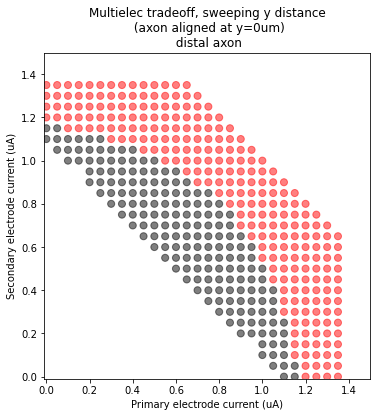

In [19]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)

i1_test = data_combined[:,0]
i2_test = data_combined[:,1]
spikes_test = data_combined[:,2]
spike_init_test = data_combined[:,3]

# # Create color_map from spikes where spikes=1 is red and spikes=0 is black
# color_map = ['black' if x == 0 else 'red' for x in spikes_test] 

# ax.scatter(np.abs(i1_test),np.abs(i2_test),c=color_map,s=50,alpha=0.5)

# Create color_map from spikes where spikes=1 is red and spikes=0 is black
color_map = ['black' if x == 0 else 'red' for x in spikes] 

ax.scatter(np.abs(i1),np.abs(i2),c=color_map,s=50,alpha=0.5)

ax.set_aspect('equal')
ax.set_xlabel('Primary electrode current (uA)')
ax.set_ylabel('Secondary electrode current (uA)')
ax.set_xlim(-0.01,1.5)
ax.set_ylim(-0.01,1.5)
ax.set_title('Multielec tradeoff, sweeping y distance\n (axon aligned at y=0um)\n distal axon')

In [103]:
# remove np.inf from init_segs
init_segs = [x for x in init_segs if x != np.inf]
print(np.unique(init_segs))
bins = np.arange(np.min(init_segs), np.max(init_segs)+1, 1)
print(bins)

[159 160 161 162 163 164 165 166 167 168 169 170 171]
[159 160 161 162 163 164 165 166 167 168 169 170 171]


(157.0, 173.0)

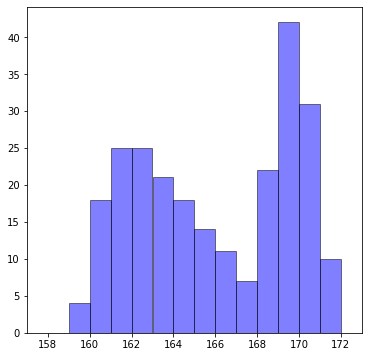

In [104]:
# Plot histogram of uniqiue spiking segments
plt.figure(figsize=(6,6))
seg_bins = np.arange(np.min(init_segs)-1, np.max(init_segs)+2, 1)
plt.hist(init_segs, bins=seg_bins, alpha=0.5, color='b', edgecolor='black')
plt.xlim([seg_bins[0]-1, seg_bins[-1]+1])

## Try out filtering to uniformly sample init segs

In [97]:
# remove np.inf from init_segs
init_segs = [x for x in spike_init_test if x != np.inf]
print(np.unique(init_segs))
bins = np.arange(np.min(init_segs), np.max(init_segs)+1, 1)
print(bins)

[160. 161. 162. 163. 164. 165. 166. 167. 168. 169. 170. 171.]
[160. 161. 162. 163. 164. 165. 166. 167. 168. 169. 170. 171.]


(158.0, 173.0)

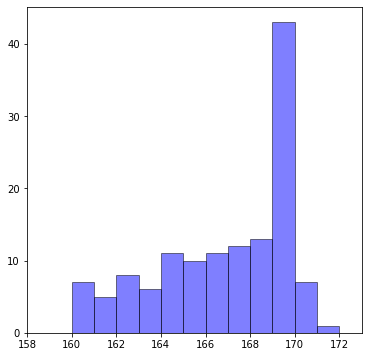

In [98]:
# Plot histogram of uniqiue spiking segments
plt.figure(figsize=(6,6))
seg_bins = np.arange(np.min(init_segs)-1, np.max(init_segs)+2, 1)
plt.hist(init_segs, bins=seg_bins, alpha=0.5, color='b', edgecolor='black')
plt.xlim([seg_bins[0]-1, seg_bins[-1]+1])

# Another iteration

In [13]:
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/real/bielec3/higherResDt/'
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/real/bielec3/0005Dt/'
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/monophasic/real/single_elec2_v2/0005Dt/'
dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/monophasic/bielec1/005Dt/'
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/single_elec1/005Dt/'

# Output the electrodes files 
filename = dir_path+'electrodes.pkl'
data = decompress_pickle(filename)
print('Electrodes: ',data)

# Find data files in dir
data_files = []
for root,dirs,files in os.walk(dir_path):
    for file in files:
        if '_' in file:
            data_files.append(file)

# Next, extract data
i1 = []
i2 = []
spikes = []
init_segs = []
for file in data_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        
        # Output substring before '_' in file
        i1.append(round(float(file.split('_')[0]),2))
        i2.append(round(float(file.split('_')[1][:-9]),2))
        spikes.append(data[0])
        init_segs.append(data[1])
        

Electrodes:  [[-1000 0 42]
 [-1030 0 42]]


In [14]:
print(init_segs)
print(i1)

[[152, 153, 154, 155], [194, 195], [], [], [154], [152, 153, 154, 155, 156, 157], [], [194, 195], [143, 144, 145, 146], [162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172], [146, 147, 148, 191, 192, 193], [143, 144, 145, 146], [], [], [], [183, 184, 185, 186], [], [152, 153, 154, 155, 156, 157], [144], [], [], [184, 185], [171, 172, 173, 174, 175, 176, 177], [165, 166, 167, 168, 169, 170, 171, 172, 173], [149, 150, 189, 190], [180, 181, 182, 183, 184, 185, 186, 187], [], [177, 178, 179, 180, 181, 182, 183], [], [144, 145, 146], [], [], [158, 159, 160, 161, 162, 163, 164], [], [], [], [157, 158, 159], [], [194, 195], [], [169, 170, 171, 172, 173, 174, 175, 176], [171, 172, 173, 174, 175, 176], [], [], [178, 179, 180, 181, 182, 183, 184], [], [], [156, 157, 158, 159], [150], [], [], [167, 168, 172], [142, 143, 144, 145, 146], [149], [], [], [], [178, 179, 180, 181, 182, 183], [170, 171, 172], [163, 164, 165, 166, 167, 168, 169, 170, 171], [153, 154, 155, 156, 157], [], [160, 161, 162

In [15]:
# unroll list of lists
init_segs_unroll = [item for sublist in init_segs for item in sublist]


In [16]:
print(init_segs_unroll)

[152, 153, 154, 155, 194, 195, 154, 152, 153, 154, 155, 156, 157, 194, 195, 143, 144, 145, 146, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 146, 147, 148, 191, 192, 193, 143, 144, 145, 146, 183, 184, 185, 186, 152, 153, 154, 155, 156, 157, 144, 184, 185, 171, 172, 173, 174, 175, 176, 177, 165, 166, 167, 168, 169, 170, 171, 172, 173, 149, 150, 189, 190, 180, 181, 182, 183, 184, 185, 186, 187, 177, 178, 179, 180, 181, 182, 183, 144, 145, 146, 158, 159, 160, 161, 162, 163, 164, 157, 158, 159, 194, 195, 169, 170, 171, 172, 173, 174, 175, 176, 171, 172, 173, 174, 175, 176, 178, 179, 180, 181, 182, 183, 184, 156, 157, 158, 159, 150, 167, 168, 172, 142, 143, 144, 145, 146, 149, 178, 179, 180, 181, 182, 183, 170, 171, 172, 163, 164, 165, 166, 167, 168, 169, 170, 171, 153, 154, 155, 156, 157, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 155, 183, 184, 185, 186, 187, 144, 145, 146, 151, 152, 153, 154, 155, 156, 192, 193, 194, 172, 172, 173, 174, 175, 176,

In [17]:
print(len(init_segs))
print(len(i1))

8100
8100


### extract only single electrode data

In [18]:
# # Extract single electrode data 
# i1 = []
# i2 = []
# spikes = []
# init_segs = []
# for file in data_files:
#         filename = dir_path+str(file)
#         data = decompress_pickle(filename[:-5])
#         i1_temp = round(float(file.split('_')[0]),2)
#         i2_temp = round(float(file.split('_')[1][:-9]),2)
#         if i2_temp == 0 and i1_temp > -4:
#             i1.append(i1_temp)
#             i2.append(i2_temp)

#             spikes.append(data[0])
#             init_segs.append(data[1])

In [19]:
# # create color_map, if x in spikes is <= 170 have it be blue, otherwise green
# color_map = []
# for ii,x in enumerate(spikes):
#     if x > 0:
#         if init_segs[ii] == 159:
#             color_map.append('blue')
#         elif init_segs[ii] == 181:
#             color_map.append('red')
#         else:
#             color_map.append('grey')
#     else:
#         color_map.append('black')
color_map = []
for ii,x in enumerate(spikes):
    if x > 0:
        max_seg = max(init_segs[ii])
        min_seg = min(init_segs[ii])
        if max_seg < 180 and min_seg > 150:
            color_map.append('red')
        else:
            color_map.append('blue')
    else:
        color_map.append('black')

Text(0.5, 1.0, 'Multielec tradeoff \n (axon aligned at y=0um)\n distal axon, straddling')

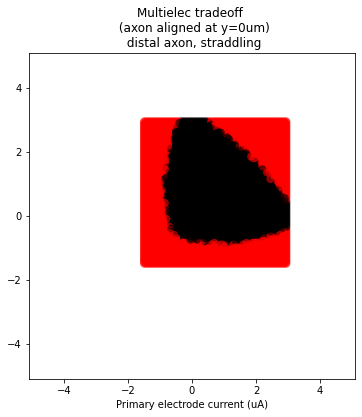

In [20]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)

# # Create color_map from spikes where spikes=1 is red and spikes=0 is black
color_map = ['black' if x == 0 else 'red' for x in spikes] 

ax.scatter(i1,i2,c=color_map,s=50,alpha=0.5)

ax.set_aspect('equal')
ax.set_xlabel('Primary electrode current (uA)')
# ax.set_ylabel('Secondary electrode current (uA)')
# ax.set_xlim(-0.01,1.8)
# ax.set_ylim(-0.01,1.8)
ax.set_xlim(-5.1,5.1)
ax.set_ylim(-5.1,5.1)
## remove y axis labels
# ax.set_yticklabels([])
ax.set_title('Multielec tradeoff \n (axon aligned at y=0um)\n distal axon, straddling')
# ax.set_title('Single electrode stimulation, aligned electrode 12um away\n red = spike; blue = spike at lobes; black = no spike')

In [22]:
# remove np.inf from init_segs
init_segs = [x for x in init_segs_unroll if x != np.inf]
print(np.unique(init_segs))
bins = np.arange(np.min(init_segs), np.max(init_segs)+1, 1)
print(bins)

[159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176
 177 178 179]
[159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176
 177 178 179]


Text(0, 0.5, 'frequency')

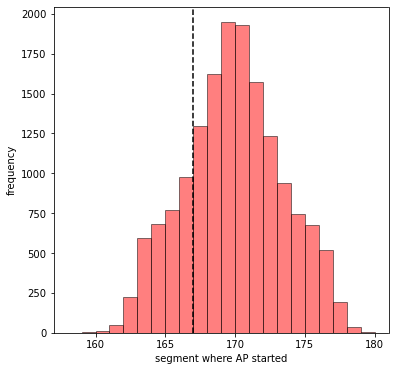

In [23]:
# Plot histogram of uniqiue spiking segments
plt.figure(figsize=(6,6))
seg_bins = np.arange(np.min(init_segs)-1, np.max(init_segs)+2, 1)
plt.hist(init_segs, bins=seg_bins, alpha=0.5, color='red', edgecolor='black')
plt.xlim([seg_bins[0]-1, seg_bins[-1]+1])

# plot a vertical line at x=170
plt.axvline(x=167, color='k', linestyle='--')
# plt.axvline(x=173, color='k', linestyle='--')
# plt.axvline(x=180, color='b', linestyle='--')
# plt.axvline(x=153, color='b', linestyle='--')
plt.xlabel('segment where AP started')
plt.ylabel('frequency')


## Save data in a datafram for Praful

In [575]:
import pandas as pd

# Initialize an empty data frame
df = pd.DataFrame(columns=['i1','i2','spike'])
df['i1'] = i1
df['i2'] = i2
df['spike'] = spikes

# Write dataframe to pickle file 
parent_dir = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/for_praful/'
filename = 'bielec_rot75.pkl'
df.to_pickle(parent_dir+filename)

In [576]:
df.head(10)

,i1,i2,spike
0,0.1,-2.8,1
1,0.3,1.2,0
2,2.5,-0.4,0
3,1.6,-0.7,0
4,0.1,-1.5,0
5,-0.3,1.2,0
6,2.3,2.1,1
7,-2.3,2.1,0
8,1.0,-1.1,0
9,0.7,-0.3,0


## Below is code to generate the multisite graphic

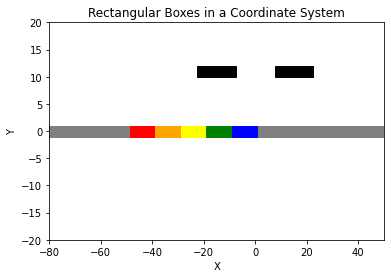

In [294]:
# Make a plot with rectangular boxes of some width at certain x,y locations

# Define the x positions for the boxes
x = [-49, -39, -29, -19, -9]

# Create a plot
fig, ax = plt.subplots()

# Plot the rectangular boxes
ax.add_patch(plt.Rectangle((x[0], -1), 10, 2, color='red'))
ax.add_patch(plt.Rectangle((x[1], -1), 10, 2, color='orange'))
ax.add_patch(plt.Rectangle((x[2], -1), 10, 2, color='yellow'))
ax.add_patch(plt.Rectangle((x[3], -1), 10, 2, color='green'))
ax.add_patch(plt.Rectangle((x[4], -1), 10, 2, color='blue'))
ax.add_patch(plt.Rectangle((-200, -1), (x[0]+200), 2, color='grey'))
ax.add_patch(plt.Rectangle((x[4]+10, -1), (200), 2, color='grey'))

ax.add_patch(plt.Rectangle((-15-(15/2), 10), 15, 2, color='black'))
ax.add_patch(plt.Rectangle((15-(15/2), 10), 15, 2, color='black'))

# Set the x and y limits
ax.set_xlim(-80, 50)
ax.set_ylim(-20, 20)

# Set labels and title
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Rectangular Boxes in a Coordinate System')

# Display the plot
plt.show()


## Include some code to generate overlapping histograms 

In [265]:
## Read in triphasic multisite data: single electrode, bielectrode, and
##  bielectrode straddling 
dir_paths = ['/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/monophasic/bielec2/005Dt/',
'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/monophasic/bielec1/005Dt/', 
'/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/monophasic/single_elec1/005Dt/']

hist_data = {}
for dir_path in dir_paths:
    # Output the electrodes files 
    filename = dir_path+'electrodes.pkl'
    data = decompress_pickle(filename)
    print('Electrodes: ',data)

    # Find data files in dir
    data_files = []
    for root,dirs,files in os.walk(dir_path):
        for file in files:
            if '_' in file:
                data_files.append(file)

    # Next, extract data
    i1 = []
    i2 = []
    spikes = []
    init_segs = []
    for file in data_files:
            filename = dir_path+str(file)
            data = decompress_pickle(filename[:-5])
            spikes.append(data[0])
            init_segs.append(data[1])
            # Output substring before '_' in file
            i1.append(round(float(file.split('_')[0]),2))
            i2.append(round(float(file.split('_')[1][:-9]),2))
    
    hist_data[dir_path] = {}
    hist_data[dir_path]['i1'] = i1
    hist_data[dir_path]['i2'] = i2
    hist_data[dir_path]['spikes'] = spikes
    hist_data[dir_path]['init_segs'] = init_segs

    # unroll init_segs and store
    init_segs_unroll = [item for sublist in init_segs for item in sublist]
    hist_data[dir_path]['init_segs_unrolled'] = init_segs_unroll

Electrodes:  [[-1000 15 42]
 [-1000 -15 42]]


Electrodes:  [[-1000 0 42]
 [-1030 0 42]]
Electrodes:  [[-1000 0 42]
 [-1000 0 42]]


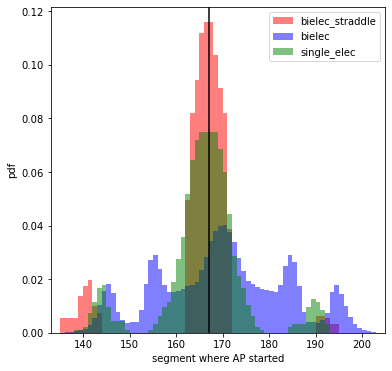

In [266]:
labels = ['bielec_straddle','bielec','single_elec']
colors = ['red','blue','green']

# define general bins for all case
# seg_bins = np.arange(158, 181, 1)
seg_bins = np.arange(134, 205, 1)

# define general plot 
fig,ax = plt.subplots(1,1,figsize=(6,6))

for ii,key in enumerate(hist_data.keys()):
    init_segs_unroll = hist_data[key]['init_segs_unrolled']
    init_segs = [x for x in init_segs_unroll if x != np.inf]
    ax.hist(init_segs, bins=seg_bins, alpha=0.5, color=colors[ii], edgecolor=None, 
                label = labels[ii], density=True)
    ax.set_xlim([seg_bins[0]-1, seg_bins[-1]+1])

ax.set_xlabel('segment where AP started')
ax.set_ylabel('pdf')
plt.axvline(x=167,c='k')
plt.legend()
plt.show()

In [254]:
data = hist_data['/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/bielec2/005Dt/']

## Create filtered version of i1 and i2 to plot against Jepson data (first the nonlinear case)

In [4]:
dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/bielec1/005Dt/'

# Output the electrodes files 
filename = dir_path+'electrodes.pkl'
data = decompress_pickle(filename)
print('Electrodes: ',data)

# Find data files in dir
data_files = []
for root,dirs,files in os.walk(dir_path):
    for file in files:
        if '_' in file:
            data_files.append(file)

# Next, extract data
i1 = []
i2 = []
spikes = []
init_segs = []
for file in data_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        
        # Output substring before '_' in file
        i1_data = round(float(file.split('_')[0]),2)
        i2_data = round(float(file.split('_')[1][:-9]),2)

        # Filter to match Jepson filtering 
        if i1_data < 0 and (i2_data < 4 and i2_data > -4):
            i1.append(i1_data)
            i2.append(i2_data)
            spikes.append(data[0])
            init_segs.append(data[1])

Electrodes:  [[-1000 0 42]
 [-1030 0 42]]


In [22]:
current_range = np.arange(-2,0.05,0.05)
print(current_range)

[-2.00000000e+00 -1.95000000e+00 -1.90000000e+00 -1.85000000e+00
 -1.80000000e+00 -1.75000000e+00 -1.70000000e+00 -1.65000000e+00
 -1.60000000e+00 -1.55000000e+00 -1.50000000e+00 -1.45000000e+00
 -1.40000000e+00 -1.35000000e+00 -1.30000000e+00 -1.25000000e+00
 -1.20000000e+00 -1.15000000e+00 -1.10000000e+00 -1.05000000e+00
 -1.00000000e+00 -9.50000000e-01 -9.00000000e-01 -8.50000000e-01
 -8.00000000e-01 -7.50000000e-01 -7.00000000e-01 -6.50000000e-01
 -6.00000000e-01 -5.50000000e-01 -5.00000000e-01 -4.50000000e-01
 -4.00000000e-01 -3.50000000e-01 -3.00000000e-01 -2.50000000e-01
 -2.00000000e-01 -1.50000000e-01 -1.00000000e-01 -5.00000000e-02
  1.77635684e-15]


In [5]:
# unroll list of lists
init_segs_unroll = [item for sublist in init_segs for item in sublist]

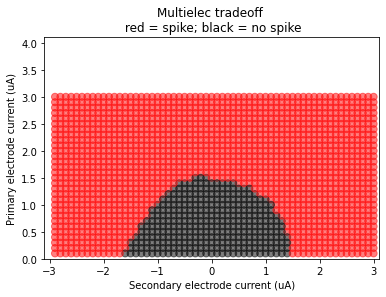

In [10]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)

# # Create color_map from spikes where spikes=1 is red and spikes=0 is black
color_map = ['black' if x == 0 else 'red' for x in spikes] 

i1_swapP = [x * -1 for x in i1]
i2_swapP = [x * -1 for x in i2]

ax.scatter(i2_swapP,i1_swapP,c=color_map,s=50,alpha=0.5)

ax.set_aspect('equal')
ax.set_xlabel('Secondary electrode current (uA)')
ax.set_ylabel('Primary electrode current (uA)')
# ax.set_xlim(-0.01,1.8)
# ax.set_ylim(-0.01,1.8)
ax.set_xlim(-3.1,3.1)
ax.set_ylim(0,4.1)
## remove y axis labels
# ax.set_yticklabels([])
ax.set_title('Multielec tradeoff \n red = spike; black = no spike')
# plt.savefig("figure3_B_nonlinear.pdf",format="pdf", bbox_inches="tight")


In [326]:
# remove np.inf from init_segs
init_segs_nonlinear = [x for x in init_segs_unroll if x != np.inf]
print(np.unique(init_segs_nonlinear))
seg_bins = np.arange(np.min(init_segs_nonlinear), np.max(init_segs_nonlinear)+1, 1)
print(seg_bins)

[160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177
 178 179]
[160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177
 178 179]


Text(0, 0.5, 'frequency')

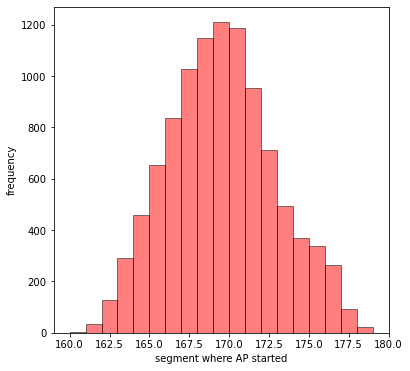

In [327]:
# Plot histogram of uniqiue spiking segments
plt.figure(figsize=(6,6))
plt.hist(init_segs_nonlinear, bins=seg_bins, alpha=0.5, color='red', edgecolor='black')
plt.xlim([seg_bins[0]-1, seg_bins[-1]+1])

# plot a vertical line at x=170
# plt.axvline(x=167, color='k', linestyle='--')
# plt.axvline(x=173, color='k', linestyle='--')
# plt.axvline(x=180, color='b', linestyle='--')
# plt.axvline(x=153, color='b', linestyle='--')
plt.xlabel('segment where AP started')
plt.ylabel('frequency')

## Now, look into the more linear case

In [27]:
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/bielec5/005Dt/'
dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/fig3_B/005Dt/'

# Output the electrodes files 
filename = dir_path+'electrodes.pkl'
data = decompress_pickle(filename)
print('Electrodes: ',data)

# Find data files in dir
data_files = []
for root,dirs,files in os.walk(dir_path):
    for file in files:
        if '_' in file:
            data_files.append(file)

# Next, extract data
i1 = []
i2 = []
spikes = []
init_segs = []
for file in data_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        
        # Output substring before '_' in file
        i1_data = round(float(file.split('_')[0]),2)
        i2_data = round(float(file.split('_')[1][:-9]),2)

        # Filter to match Jepson filtering 
        if (i1_data < 0 and i1_data > -2) and (i2_data < 2 and i2_data > -2):
            i1.append(i1_data)
            i2.append(i2_data)
            spikes.append(data[0])
            init_segs.append(data[1])

Electrodes:  [[-1015 15 42]
 [-1015 -15 42]]


In [28]:
# unroll list of lists
init_segs_unroll = [item for sublist in init_segs for item in sublist]

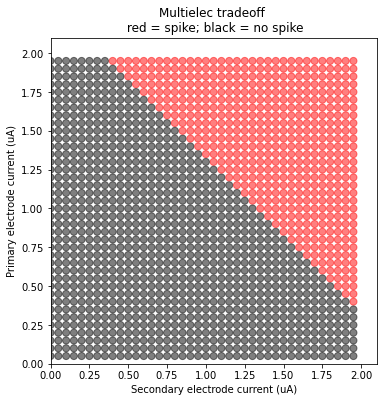

In [30]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)

# # Create color_map from spikes where spikes=1 is red and spikes=0 is black
color_map = ['black' if x == 0 else 'red' for x in spikes] 

i1_swapP = [x * -1 for x in i1]
i2_swapP = [x * -1 for x in i2]

ax.scatter(i2_swapP,i1_swapP,c=color_map,s=50,alpha=0.5)

ax.set_aspect('equal')
ax.set_xlabel('Secondary electrode current (uA)')
ax.set_ylabel('Primary electrode current (uA)')
# ax.set_xlim(-0.01,1.8)
# ax.set_ylim(-0.01,1.8)
# ax.set_xlim(-2.1,2.1)
ax.set_xlim(0,2.1)
ax.set_ylim(0,2.1)
## remove y axis labels
# ax.set_yticklabels([])
ax.set_title('Multielec tradeoff \n red = spike; black = no spike')
plt.savefig("figure3_B_linear.pdf",format="pdf", bbox_inches="tight")


In [359]:
# remove np.inf from init_segs
init_segs_linear = [x for x in init_segs_unroll if x != np.inf]
# print(np.unique(init_segs))
# bins = np.arange(np.min(init_segs), np.max(init_segs)+1, 1)
# print(bins)

Text(0, 0.5, 'frequency')

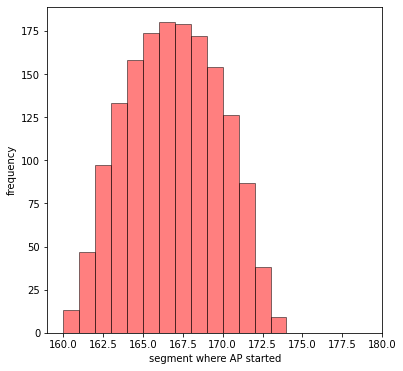

In [360]:
# Plot histogram of uniqiue spiking segments
plt.figure(figsize=(6,6))
plt.hist(init_segs_linear, bins=seg_bins, alpha=0.5, color='red', edgecolor='black')
plt.xlim([seg_bins[0]-1, seg_bins[-1]+1])

# plot a vertical line at x=170
# plt.axvline(x=167, color='k', linestyle='--')
# plt.axvline(x=173, color='k', linestyle='--')
# plt.axvline(x=180, color='b', linestyle='--')
# plt.axvline(x=153, color='b', linestyle='--')
plt.xlabel('segment where AP started')
plt.ylabel('frequency')

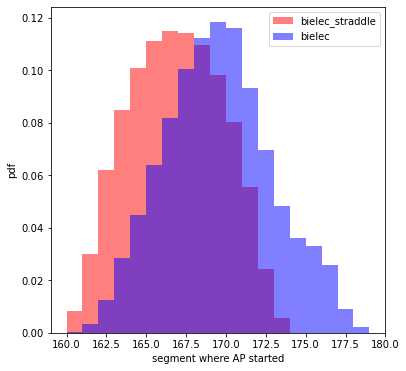

In [361]:
# plot overlaid histograms
plt.figure(figsize=(6,6))
plt.hist(init_segs_linear, bins=seg_bins, alpha=0.5, color='red', edgecolor=None, density=True, label='bielec_straddle')
plt.hist(init_segs_nonlinear, bins=seg_bins, alpha=0.5, color='blue', edgecolor=None, density=True, label='bielec')
plt.xlim([seg_bins[0]-1, seg_bins[-1]+1])
plt.xlabel('segment where AP started')
plt.ylabel('pdf')
plt.legend()
plt.show()


## Repeat historgrams, but this time normalize spiking counts 

In [49]:
dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/fig3_y15/005Dt/'

# Output the electrodes files 
filename = dir_path+'electrodes.pkl'
data = decompress_pickle(filename)
print('Electrodes: ',data)

# Find data files in dir
data_files = []
for root,dirs,files in os.walk(dir_path):
    for file in files:
        if '_' in file:
            data_files.append(file)

# Next, extract data
i1 = []
i2 = []
spikes = []
init_segs = []
for file in data_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        
        # Output substring before '_' in file
        curr1 = round(float(file.split('_')[0]),2)
        curr2 = round(float(file.split('_')[1][:-9]),2)
        if np.abs(curr1) < 3.1 and np.abs(curr2) < 3.1:
            i1.append(round(float(file.split('_')[0]),2))
            i2.append(round(float(file.split('_')[1][:-9]),2))
            spikes.append(data[0])
            init_segs.append(data[1])

Electrodes:  [[-1030 0 52]
 [-1000 0 52]]


In [39]:
# unroll list of lists
init_segs_unroll = [item for sublist in init_segs for item in sublist]

In [40]:
# Make list of unique segments, these are the bins
bins = np.unique(init_segs_unroll)
print('List of unique segs:\n', bins)

List of unique segs:
 [163 164 165 166 167 168 169 170 171 172 173 174 175]


In [41]:
# make an empty list of zeros of same length as bins
counts = np.zeros(len(bins))
print(counts)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [42]:
# march through init_segs, adjusting spike count normalized by number of spiking segs
counts = np.zeros(len(bins))
for lst in init_segs:
    # If spiking
    if len(lst) > 0:
        normalized_spike = 1/len(lst)
        for seg in lst:
           # Find index of seg in bins and normalized_spike to same counts idx 
           idx = np.argwhere(bins == seg)[0][0]
           counts[idx] += normalized_spike


In [43]:
print(counts)

[ 0.46153846  8.32517483 34.96406371 33.57120657 33.07120657 43.1545399
 36.1545399  43.1545399  33.07120657 33.57120657 34.71406371  8.32517483
  0.46153846]


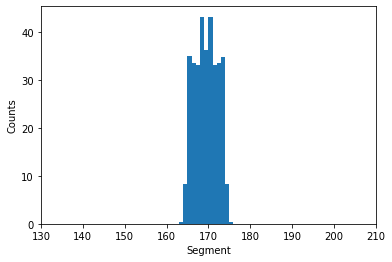

In [44]:
# Plot the histogram from pre-counted data
plt.bar(bins, counts, width=1, align='edge')

# Adding labels and title
plt.xlabel('Segment')
plt.ylabel('Counts')
plt.xlim([130,210])
# plt.xlim([140,200])

# Show the plot
plt.show()

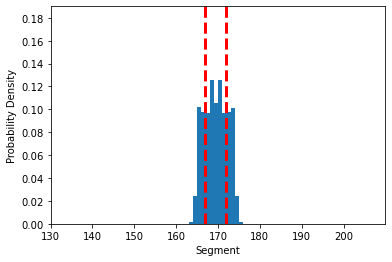

In [45]:
total_counts = sum(counts)
# total_counts = 2412.0
bin_width = bins[1] - bins[0]
normalized_counts = [count / (total_counts * bin_width) for count in counts]
# Plot the normalized histogram from pre-counted data
plt.bar(bins, normalized_counts, width=1, align='edge')

# Adding labels and title
plt.xlabel('Segment')
plt.ylabel('Probability Density')
plt.xlim([130, 210])
# plt.xlim([140, 200])
plt.ylim([0,0.19])
# plot xticks every 1
plt.xticks(np.arange(130, 210, 10))
plt.yticks(np.arange(0, 0.19, 0.02))
plt.axvline(172, color='r', linewidth=3, linestyle='--')
plt.axvline(167, color='r', linewidth=3, linestyle='--')
# plt.xticks(np.arange(140, 200, 1))
# plt.savefig("figure4_A_triphasic_hist.pdf",format="pdf", bbox_inches="tight")
plt.show()

In [36]:
print(total_counts)

813.0000000000041


Text(0.5, 1.0, 'Multielec tradeoff \n (axon aligned at y=0um)\n distal axon, straddling')

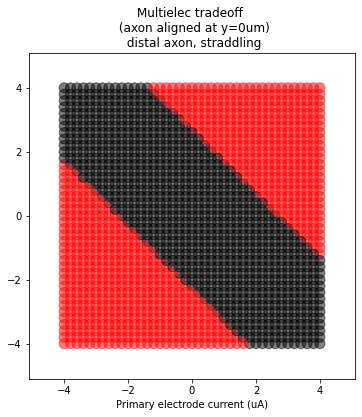

In [37]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)

# # Create color_map from spikes where spikes=1 is red and spikes=0 is black
color_map = ['black' if x == 0 else 'red' for x in spikes] 

# ax.scatter(i1,i2,c=color_map,s=50,alpha=0.5)
ax.scatter(i1,i2,c=color_map,s=100,alpha=0.5)

ax.set_aspect('equal')
ax.set_xlabel('Primary electrode current (uA)')
# ax.set_ylabel('Secondary electrode current (uA)')
# ax.set_xlim(-0.01,1.8)
# ax.set_ylim(-0.01,1.8)
ax.set_xlim(-5.1,5.1)
ax.set_ylim(-5.1,5.1)
## remove y axis labels
# ax.set_yticklabels([])
ax.set_title('Multielec tradeoff \n (axon aligned at y=0um)\n distal axon, straddling')
# plt.savefig("figure4_A_biphasic.pdf",format="pdf", bbox_inches="tight")
# ax.set_title('Single electrode stimulation, aligned electrode 12um away\n red = spike; blue = spike at lobes; black = no spike')

## Calculate bi-electtrode rotations around the cell positioning

In [117]:
# Define rotation matrix for a line segment about the origin 
rot_deg = 75
theta = np.deg2rad(rot_deg) 
rot_mat = np.array([[np.cos(theta), -1*np.sin(theta)],
                    [np.sin(theta), np.cos(theta)]])

point1 = np.array([-15, 0])
point2 = np.array([15, 0])


In [118]:
point1_rot = np.round(np.matmul(point1, rot_mat),2)
point2_rot = np.round(np.matmul(point2, rot_mat),2)

print(point1_rot)
print(point2_rot)

[-3.88 14.49]
[  3.88 -14.49]


In [119]:
elec1 = [-1015+point1_rot[0],0+point1_rot[1]]
elec2 = [-1015+point2_rot[0],0+point2_rot[1]]

print(elec1)
print(elec2)

[-1018.88, 14.49]
[-1011.12, -14.49]
